In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

meal_dataset = pd.read_parquet('../data/meal_dataset.parquet')
glucose = pd.read_parquet('../data/glucose_timeseries.parquet')


In [115]:
print(meal_dataset.dtypes)
print(meal_dataset['window'].value_counts())

meal_id                                                   int64
DietaryCarbohydrates                                    float64
DietaryEnergyConsumed                                   float64
DietaryFatTotal                                         float64
DietaryFiber                                            float64
DietaryProtein                                          float64
meal_start               datetime64[ns, pytz.FixedOffset(-240)]
meal_end                 datetime64[ns, pytz.FixedOffset(-240)]
window                                                    int64
baseline_glucose                                        float64
peak_rise                                               float64
iauc                                                    float64
n_baseline_pts                                          float64
n_response_pts                                          float64
pre_steps                                               float64
pre_active_energy                       

In [116]:
meal_dataset['meal_hour_sin'] = np.sin(2 * np.pi * meal_dataset['meal_start'].dt.hour / 24)
meal_dataset['meal_hour_cos'] = np.cos(2 * np.pi * meal_dataset['meal_start'].dt.hour / 24)

In [117]:
meal_dataset.columns

Index(['meal_id', 'DietaryCarbohydrates', 'DietaryEnergyConsumed',
       'DietaryFatTotal', 'DietaryFiber', 'DietaryProtein', 'meal_start',
       'meal_end', 'window', 'baseline_glucose', 'peak_rise', 'iauc',
       'n_baseline_pts', 'n_response_pts', 'pre_steps', 'pre_active_energy',
       'pre_hr', 'post_steps', 'post_active_energy', 'post_hr',
       'walked_after_eating', 'hours_slept', 'meal_hour_sin', 'meal_hour_cos'],
      dtype='object')

In [118]:
meal_dataset[['peak_rise','iauc']].head()

,peak_rise,iauc
0,0.481060,28.262475
1,0.333043,11.518092
2,1.480200,68.274400
3,1.036137,55.692258
4,3.367457,163.423117


## Target distributions 

In [119]:
def plot_feature_distribution(windows, feature):
    bins = np.linspace(meal_dataset[feature].min(), meal_dataset[feature].max(), 16)

    groups = [meal_dataset[meal_dataset['window'] == w][feature] for w in windows]
    _, p = stats.mannwhitneyu(*groups, alternative='two-sided')


    fig, axes = plt.subplots(1, len(windows), sharex=True, sharey=True, figsize=(8,4))
    for ax, w in zip(axes, windows):
        subset = meal_dataset[meal_dataset['window']==w]
        ax.hist(subset[feature], bins=bins)
        ax.set_title(f'window {w}')
    plt.suptitle(f'{feature} Distribution  (Mann-Whitney p={p:.3f})')
    plt.xlabel(f'{feature}')
    plt.tight_layout()
    plt.show()

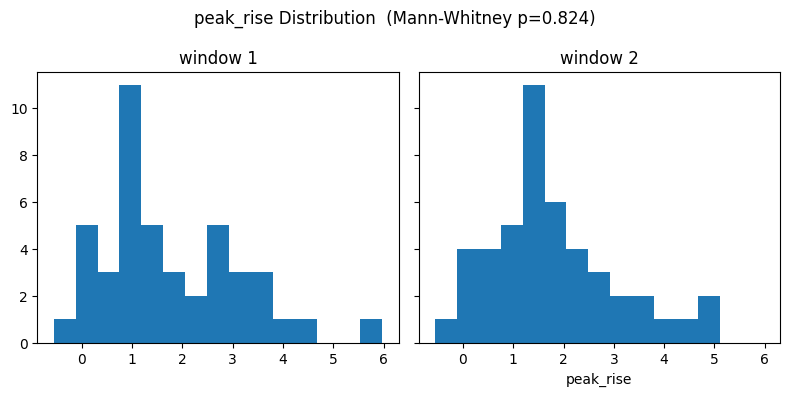

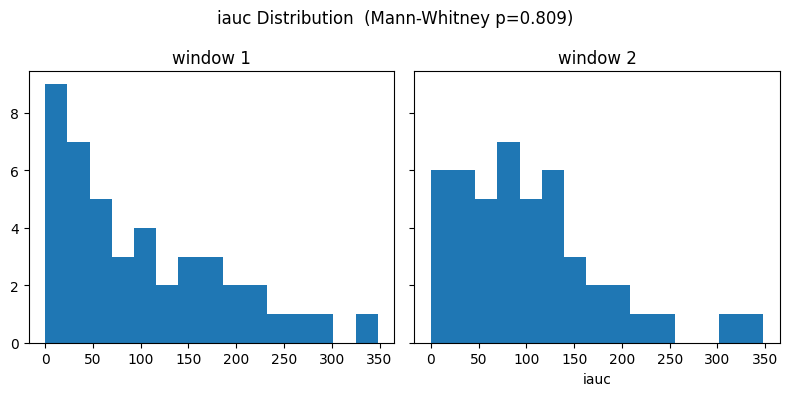

In [120]:
windows = meal_dataset['window'].unique()
for feature in ['peak_rise', 'iauc']:
    plot_feature_distribution(windows, feature)

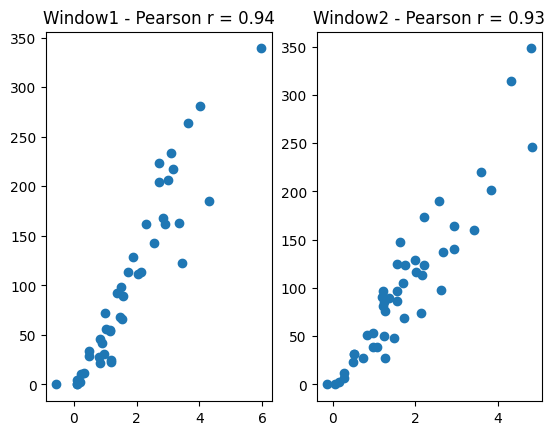

In [121]:
windows = meal_dataset['window'].unique()
fig, axes = plt.subplots(1, len(windows))

for ax,w in zip(axes, windows):
    subset = meal_dataset[meal_dataset['window']==w]
    ax.scatter(subset['peak_rise'], subset['iauc'])
    pearson = np.corrcoef(subset['peak_rise'], subset['iauc'])[0,1]
    ax.set_title(f'Window{w} - Pearson r = {pearson:.2f}')

## Feature Distribution

In [122]:
meal_dataset.columns

Index(['meal_id', 'DietaryCarbohydrates', 'DietaryEnergyConsumed',
       'DietaryFatTotal', 'DietaryFiber', 'DietaryProtein', 'meal_start',
       'meal_end', 'window', 'baseline_glucose', 'peak_rise', 'iauc',
       'n_baseline_pts', 'n_response_pts', 'pre_steps', 'pre_active_energy',
       'pre_hr', 'post_steps', 'post_active_energy', 'post_hr',
       'walked_after_eating', 'hours_slept', 'meal_hour_sin', 'meal_hour_cos'],
      dtype='object')

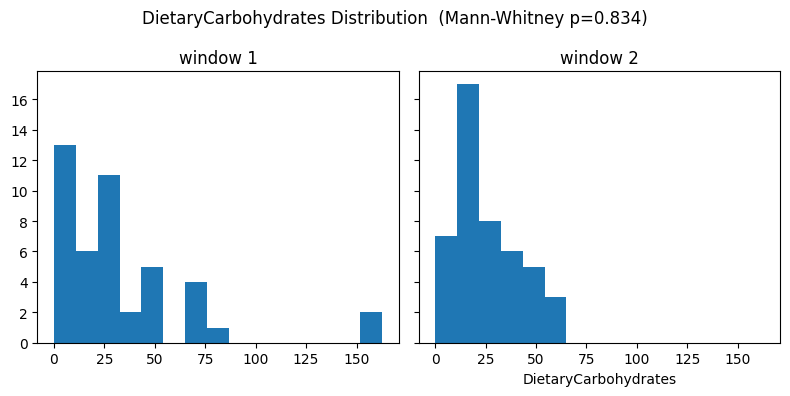

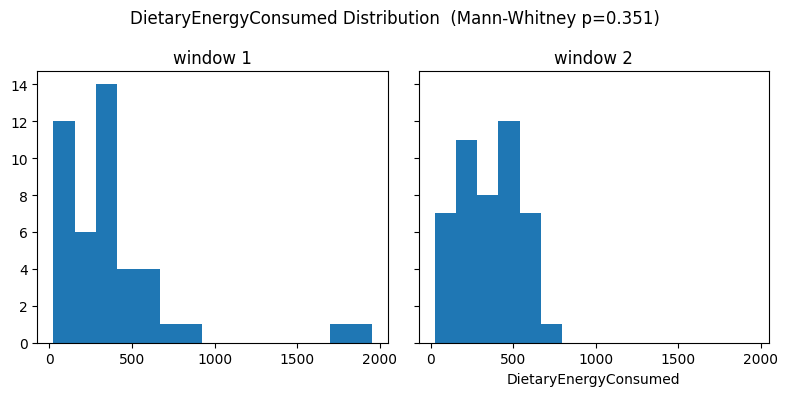

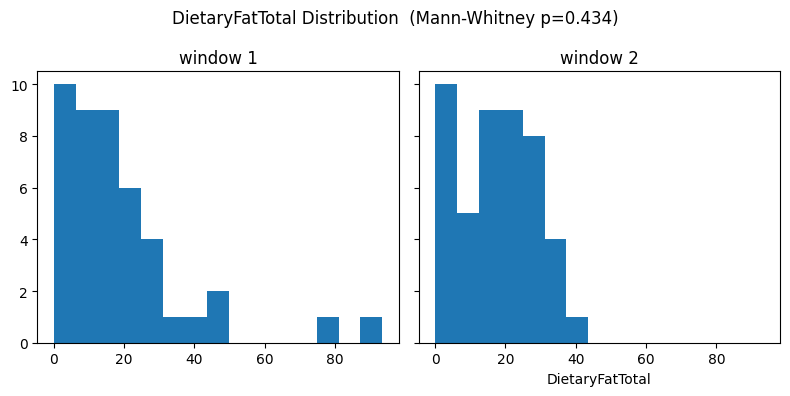

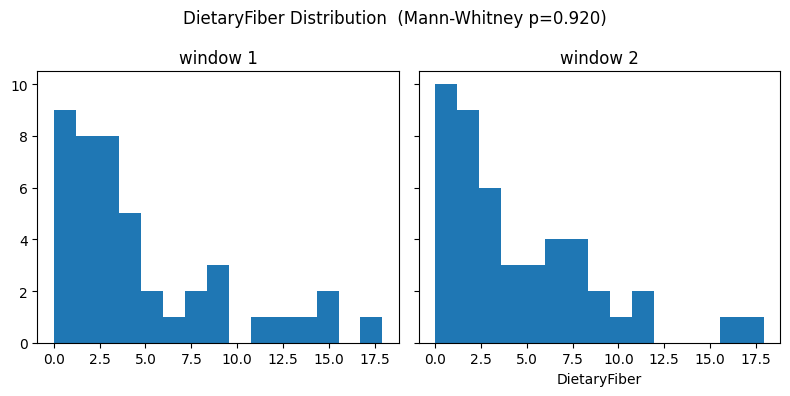

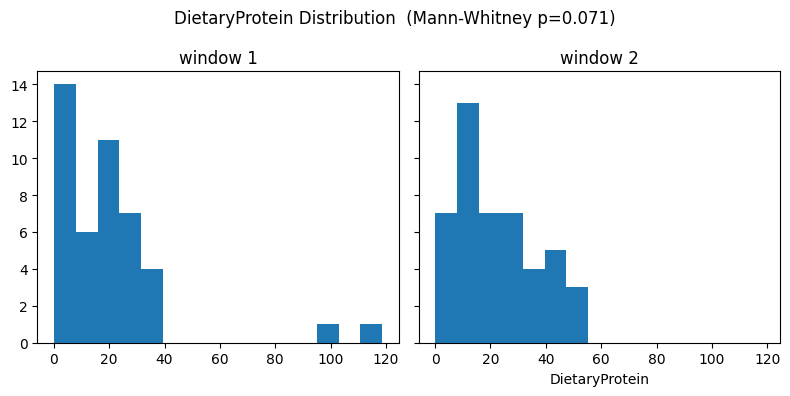

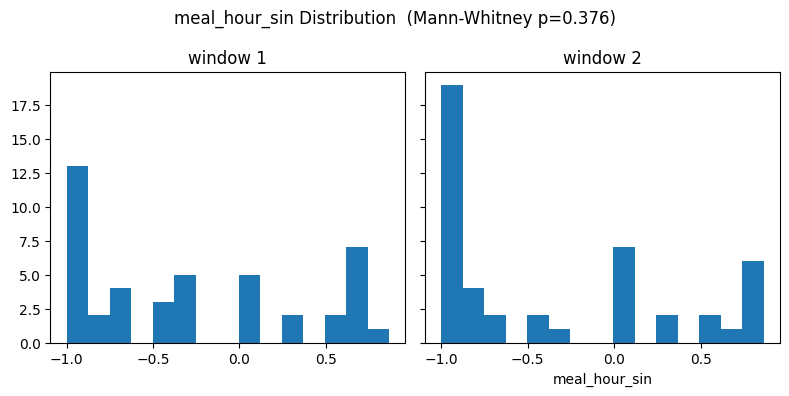

In [123]:
for feature in ['DietaryCarbohydrates', 'DietaryEnergyConsumed', 'DietaryFatTotal', 'DietaryFiber', 'DietaryProtein', 'meal_hour_sin']:
    plot_feature_distribution(windows, feature)


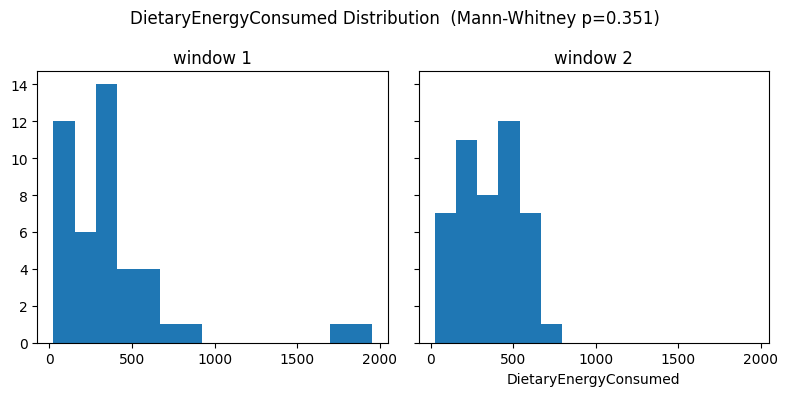

In [124]:
plot_feature_distribution(windows, 'DietaryEnergyConsumed')

In [125]:
from scipy import stats

features = ['peak_rise', 'iauc', 'DietaryCarbohydrates', 'DietaryEnergyConsumed',
            'DietaryFatTotal', 'DietaryFiber', 'DietaryProtein']

rows = []
for feature in features:
    groups = [meal_dataset[meal_dataset['window'] == w][feature] for w in windows]
    _, p = stats.mannwhitneyu(*groups, alternative='two-sided')
    row = {'feature': feature}
    for w, g in zip(windows, groups):
        row[f'w{w}_mean'] = g.mean().round(2)
        row[f'w{w}_std'] = g.std().round(2)
        row[f'w{w}_median'] = g.median().round(2)
    row['p_value'] = round(p, 3)
    row['significant'] = p < 0.05
    rows.append(row)

summary = pd.DataFrame(rows).set_index('feature')
summary


,w1_mean,w1_std,w1_median,w2_mean,w2_std,w2_median,p_value,significant
feature,,,,,,,,
peak_rise,1.77,1.36,1.49,1.76,1.21,1.55,0.824,False
iauc,102.23,87.61,80.42,101.47,78.16,90.34,0.809,False
DietaryCarbohydrates,33.40,34.94,24.43,26.51,16.69,20.89,0.834,False
DietaryEnergyConsumed,374.56,376.87,328.24,352.78,181.03,382.58,0.351,False
DietaryFatTotal,18.93,18.85,14.76,17.90,10.72,17.13,0.434,False
DietaryFiber,4.63,4.57,3.04,4.60,4.17,3.24,0.920,False
DietaryProtein,19.82,22.36,17.92,22.77,14.19,19.40,0.071,False


In [126]:
meal_dataset.columns

Index(['meal_id', 'DietaryCarbohydrates', 'DietaryEnergyConsumed',
       'DietaryFatTotal', 'DietaryFiber', 'DietaryProtein', 'meal_start',
       'meal_end', 'window', 'baseline_glucose', 'peak_rise', 'iauc',
       'n_baseline_pts', 'n_response_pts', 'pre_steps', 'pre_active_energy',
       'pre_hr', 'post_steps', 'post_active_energy', 'post_hr',
       'walked_after_eating', 'hours_slept', 'meal_hour_sin', 'meal_hour_cos'],
      dtype='object')

In [127]:
meal_dataset['walked_after_eating'].value_counts()

walked_after_eating
1.0    61
0.0    29
Name: count, dtype: int64

In [128]:
grouped = meal_dataset.groupby(['window','walked_after_eating']).size().reset_index(name='Count')
grouped['pct'] = (grouped['Count'] / grouped.groupby('window')['Count'].transform('sum') * 100).round(1)
grouped

,window,walked_after_eating,Count,pct
0,1,0.0,10,22.7
1,1,1.0,34,77.3
2,2,0.0,19,41.3
3,2,1.0,27,58.7


## Modeling

In [129]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

features = ['DietaryCarbohydrates', 'DietaryEnergyConsumed', 'DietaryFatTotal', 'DietaryFiber', 'DietaryProtein',
            'meal_hour_sin', 'meal_hour_cos']
# features = ['DietaryCarbohydrates', 'meal_hour_sin', 'meal_hour_cos', 'walked_after_eating']

X = meal_dataset[features]
y = meal_dataset['peak_rise']

model = LinearRegression()
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(scores, scores.mean())

[ 0.37912124 -1.13441524 -0.06307994 -0.4254294  -0.54650184] -0.3580610374665613


In [130]:
meal_dataset[features].corr()

,DietaryCarbohydrates,DietaryEnergyConsumed,DietaryFatTotal,DietaryFiber,DietaryProtein,meal_hour_sin,meal_hour_cos
DietaryCarbohydrates,1.000000,0.891050,0.719092,0.741217,0.741324,-0.108798,0.045499
DietaryEnergyConsumed,0.891050,1.000000,0.938016,0.757176,0.914528,-0.070907,-0.079768
DietaryFatTotal,0.719092,0.938016,1.000000,0.691100,0.818882,-0.034977,-0.152820
DietaryFiber,0.741217,0.757176,0.691100,1.000000,0.677837,-0.110223,-0.002236
DietaryProtein,0.741324,0.914528,0.818882,0.677837,1.000000,-0.050271,-0.094058
meal_hour_sin,-0.108798,-0.070907,-0.034977,-0.110223,-0.050271,1.000000,-0.597933
meal_hour_cos,0.045499,-0.079768,-0.152820,-0.002236,-0.094058,-0.597933,1.000000


In [131]:
meal_dataset.columns

Index(['meal_id', 'DietaryCarbohydrates', 'DietaryEnergyConsumed',
       'DietaryFatTotal', 'DietaryFiber', 'DietaryProtein', 'meal_start',
       'meal_end', 'window', 'baseline_glucose', 'peak_rise', 'iauc',
       'n_baseline_pts', 'n_response_pts', 'pre_steps', 'pre_active_energy',
       'pre_hr', 'post_steps', 'post_active_energy', 'post_hr',
       'walked_after_eating', 'hours_slept', 'meal_hour_sin', 'meal_hour_cos'],
      dtype='object')

In [132]:
export = meal_dataset[['meal_id', 'meal_start', 'meal_end', 'DietaryCarbohydrates', 'DietaryEnergyConsumed']].copy()
export['meal_start'] = export['meal_start'].dt.tz_localize(None)
export['meal_end'] = export['meal_end'].dt.tz_localize(None)
export = export 
export['carb_source'] = ''
export['GI'] = ''
# export.to_excel('../data/add_carb_source.xlsx', index=False)

In [133]:
print(export.shape)
export.head(20)

(90, 7)


,meal_id,meal_start,meal_end,DietaryCarbohydrates,DietaryEnergyConsumed,carb_source,GI
0,1,2025-08-01 09:09:58,2025-08-01 09:09:58,36.00670,359.8900,,
1,2,2025-08-01 09:27:00,2025-08-01 09:27:00,3.87900,104.2200,,
2,3,2025-08-01 13:32:53,2025-08-01 13:32:53,25.40490,373.3760,,
3,4,2025-08-01 14:40:20,2025-08-01 14:40:20,21.00000,157.5000,,
4,5,2025-08-01 18:14:23,2025-08-01 18:14:23,66.09550,645.9370,,
5,6,2025-08-01 18:40:00,2025-08-01 18:40:00,8.67000,77.3950,,
6,7,2025-08-02 09:50:00,2025-08-02 09:50:00,23.45500,384.5000,,
7,8,2025-08-02 11:45:00,2025-08-02 11:45:00,65.18360,563.8370,,
8,9,2025-08-02 17:00:00,2025-08-02 17:00:00,75.82510,511.4920,,
9,10,2025-08-03 09:35:00,2025-08-03 09:35:00,31.42360,370.2400,,
